In [1]:
!git clone https://github.com/harsh3-web/Ecommerce-Recommender.git
%cd Ecommerce-Recommender
!pip install -q sentence-transformers

from google.colab import drive
drive.mount("/content/drive")
DATA = "/content/drive/MyDrive/Ecommerce-Recommender-data"

Cloning into 'Ecommerce-Recommender'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 23 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 49.71 KiB | 1.78 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Ecommerce-Recommender
Mounted at /content/drive


In [2]:
!mkdir -p datasets/images
!cp "{DATA}"/*.csv .
!cp "{DATA}"/images/*.jpg datasets/images/
!ls datasets/images | wc -l        # 200


200


In [3]:
import os
import numpy as np
import pandas as pd

products = pd.read_csv("products_expanded.csv")
images = pd.read_csv("product_images_expanded.csv")
images["exists"] = images["image_path"].apply(os.path.exists)   # True if the file is really there
print(images["exists"].value_counts())                          # should be True: 200

exists
True    200
Name: count, dtype: int64


In [4]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"   # use the GPU if one is available
cnn = resnet50(weights=ResNet50_Weights.DEFAULT)          # pretrained on ImageNet (1.2M images)
cnn.fc = torch.nn.Identity()       # remove the final classification layer -> output 2048 features
cnn = cnn.to(device).eval()        # eval mode: fixed BatchNorm, no dropout -> same output every time
print("Running on:", device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 88.4MB/s]


Running on: cpu


In [5]:
from torchvision import transforms

preprocess = transforms.Compose([                 # Compose = apply these steps in order
    transforms.Resize((224, 224)),                # ResNet50 expects 224x224 (our images are 80x60)
    transforms.ToTensor(),                        # image -> tensor of shape (3, 224, 224), values 0..1
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # ImageNet's average R, G, B values
                         std=[0.229, 0.224, 0.225]),    # ImageNet's R, G, B standard deviations
])

In [6]:
from PIL import Image

@torch.no_grad()     # don't track gradients (we're not training) -> faster, uses less memory
def embed_images(paths, batch_size=32):
    out = []
    for i in range(0, len(paths), batch_size):                  # step through paths 32 at a time
        batch = torch.stack([preprocess(Image.open(p).convert("RGB")) for p in paths[i:i + batch_size]])
        out.append(cnn(batch.to(device)).cpu().numpy())         # (32, 2048) features -> back to CPU numpy
    return np.vstack(out)                                       # stack all batches -> (n_images, 2048)

In [7]:
row_emb = embed_images(images["image_path"].tolist())     # one 2048-vector per IMAGE
print(row_emb.shape)

emb_df = pd.DataFrame(row_emb)
emb_df["product_id"] = images["product_id"].values
prod_emb = emb_df.groupby("product_id").mean()            # AVERAGE all images of the same product
prod_emb = prod_emb.reindex(products["product_id"])       # rows in product_id order 1..200

(200, 2048)


In [8]:
image_emb = prod_emb.to_numpy()
image_emb = image_emb / np.linalg.norm(image_emb, axis=1, keepdims=True)   # each row -> length 1
np.save("image_emb.npy", image_emb)        # .npy = numpy's fast binary format
!cp image_emb.npy "{DATA}/"
print(image_emb.shape)                     # (200, 2048)

(200, 2048)


In [9]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("all-MiniLM-L6-v2")
texts = (products["category"] + ". " + products["product_name"] + ". " + products["description"]).tolist()
text_emb = encoder.encode(texts, normalize_embeddings=True)    # (200, 384), already length 1
np.save("text_emb.npy", text_emb)
!cp text_emb.npy "{DATA}/"

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

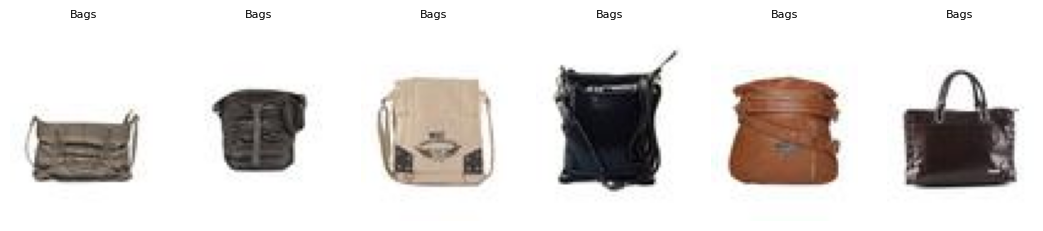

In [10]:
import matplotlib.pyplot as plt

def show_similar(pid, emb, k=5):
    sims = emb @ emb[pid - 1]                                  # cosine similarity to every product
    ids = [pid] + list(np.argsort(sims)[::-1][1:k + 1] + 1)    # the product itself + its 5 nearest
    fig, axes = plt.subplots(1, k + 1, figsize=(2.2 * (k + 1), 3))
    for ax, i in zip(axes, ids):
        ax.imshow(Image.open(f"datasets/images/{i}_1_front.jpg")); ax.axis("off")
        ax.set_title(products.loc[i - 1, "category"], fontsize=8)

show_similar(1, image_emb)      # try other ids too: 30, 80, 150 ...

In [11]:
def neighbour_purity(emb, k=5):
    """% of each product's k nearest neighbours that share its category."""
    cats = products["category"].values
    sims = emb @ emb.T
    np.fill_diagonal(sims, -1)                                 # don't count a product as its own neighbour
    nearest = np.argsort(sims, axis=1)[:, ::-1][:, :k]         # top-k neighbour indices for every product
    return (cats[nearest] == cats[:, None]).mean()

print(f"Image (ResNet50) : {neighbour_purity(image_emb):.0%}")
print(f"Text  (MiniLM)   : {neighbour_purity(text_emb):.0%}")
print("Random           : 12%   (24 same-category products out of 199 others)")

Image (ResNet50) : 85%
Text  (MiniLM)   : 95%
Random           : 12%   (24 same-category products out of 199 others)


In [13]:
##to see the purity for each category
def purity_by_category(emb, k=5):
    """Neighbour purity separately for each category."""
    cats = products["category"].values
    sims = emb @ emb.T
    np.fill_diagonal(sims, -1)                                  # ignore self-similarity
    nearest = np.argsort(sims, axis=1)[:, ::-1][:, :k]          # 5 nearest neighbours per product
    same = (cats[nearest] == cats[:, None]).mean(axis=1)        # purity for EACH product
    return pd.Series(same, index=cats).groupby(level=0).mean().sort_values()   # average per category

purity_by_category(image_emb)

,0
Jackets,0.568
T-Shirts,0.704
Shirts,0.784
Dresses,0.872
Bags,0.944
Watches,0.976
Shoes,0.984
Jeans,1.000




- Replaced synthetic products with 200 real Myntra products (25 per category)
  from Fashion Product Images (Small); price and rating still simulated
- ResNet50 (ImageNet weights, fc -> Identity) = frozen feature extractor, 2048-d
- Precomputed + saved image_emb.npy (200x2048) and text_emb.npy (200x384)
- Fixed multi-view overwrite bug: average embeddings across all views of a product

Neighbour purity (5 nearest neighbours in same category):
| Embedding | Purity |
|-----------|--------|
| Random    | 12%    |
| ResNet50  | 85%    |
| MiniLM    | 95%    |
Per-category (image): [paste output here]

ResNet50, used frozen, separated jeans, shoes and watches almost perfectly, but confused jackets with shirts and T-shirts, about 57% purity for jackets. That's because they share a similar silhouette at low resolution, and catalogue photos show models wearing layers. Fine-tuning on fashion images or using higher-resolution photos would help, but with 200 images, fine-tuning would overfit."